# Analisi preliminare referti annotati reali

# Preliminari

In [2]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import ast

In [3]:
# set plot style
plt.style.use('ggplot')

# Load Data

In [4]:
# Get data

data_path = Path('../data/base.tumoreprimitivo.csv/')
# Se il file non è presente, inserirlo manualmente prendendolo dalla cartella dropbox

data = pd.read_csv(data_path)

In [5]:
print(f'{data.shape = }')
display(data.head(2))

data.shape = (229, 45)


,id,profile,discrepanze_rilevate,motivazioni_discrepanze,radiologist,patient_id,sesso,data_nascita,interpretazioni,report_text,...,coinvolgimento_fascia_mesorettale,distanza_minima_fascia_ore,linfonodi_sospetti,numero_linfonodi_non_conosciuto,sedi_locoregionali,sedi_non_locoregionali,depositi_tumorali,numero_depositi,emvi_esteso,status
0,306,GuidoImbemba,['nessuna'],nessuna,NaN,6167209,F,1951-01-16,NaN,IN CORRISPONDENZA DELLA PARETE LATERALE DESTRA...,...,NaN,NaN,3.0,False,['mesorettali'],[],NaN,0.0,no,complete
1,305,GuidoImbemba,['nessuna'],nessuna,NaN,32798134,M,1949-01-23,NaN,SI SEGNALA LA PRESENZA IN CORRISPONDENZA DEL R...,...,NaN,NaN,0.0,True,['rettali_superiori'],[],NaN,0.0,no,complete


# Elimina righe doppie

In [6]:
print(f'Shape iniziale: {data.shape}')

# Intere righe duplicate. Keep last perchè i report hanno id decrescente
duplicati = data.iloc[:, 1:].duplicated(keep='last')
print(f'Numero righe duplicate: {duplicati.sum()}')

data_clean = data[duplicati == False]
print('Righe doppie eliminate')

# Rimuovi righe con report duplicati
duplicati = data_clean['report_text'].duplicated(keep='last')
righe_report_duplicato = data_clean[duplicati]
print(f'Numero righe con stesso referto: {duplicati.sum()}')

data_clean = data_clean[duplicati == False]
print('Righe eliminate')

data_clean.reset_index(inplace=True, drop=True)

print(f'{data_clean.shape = }')

Shape iniziale: (229, 45)
Numero righe duplicate: 0
Righe doppie eliminate
Numero righe con stesso referto: 9
Righe eliminate
data_clean.shape = (220, 45)


# Analisi preliminari delle colonne

In [7]:
print(data_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 45 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      220 non-null    int64  
 1   profile                                 220 non-null    object 
 2   discrepanze_rilevate                    220 non-null    object 
 3   motivazioni_discrepanze                 220 non-null    object 
 4   radiologist                             2 non-null      object 
 5   patient_id                              220 non-null    int64  
 6   sesso                                   218 non-null    object 
 7   data_nascita                            219 non-null    object 
 8   interpretazioni                         83 non-null     object 
 9   report_text                             220 non-null    object 
 10  morfologia                              212 non-null    object

In [8]:
# Fill NaN for plotting purposes
data_plot = data_clean.fillna('NaN')
data_ilaria = data_plot[data_plot['profile'] == 'IlariaNacci']
data_plot = data_plot.drop(index=data_plot[data_plot['profile'] == 'IlariaNacci'].index)

## Colonne extra
Colonne non rilevanti per l'allenamento del modello

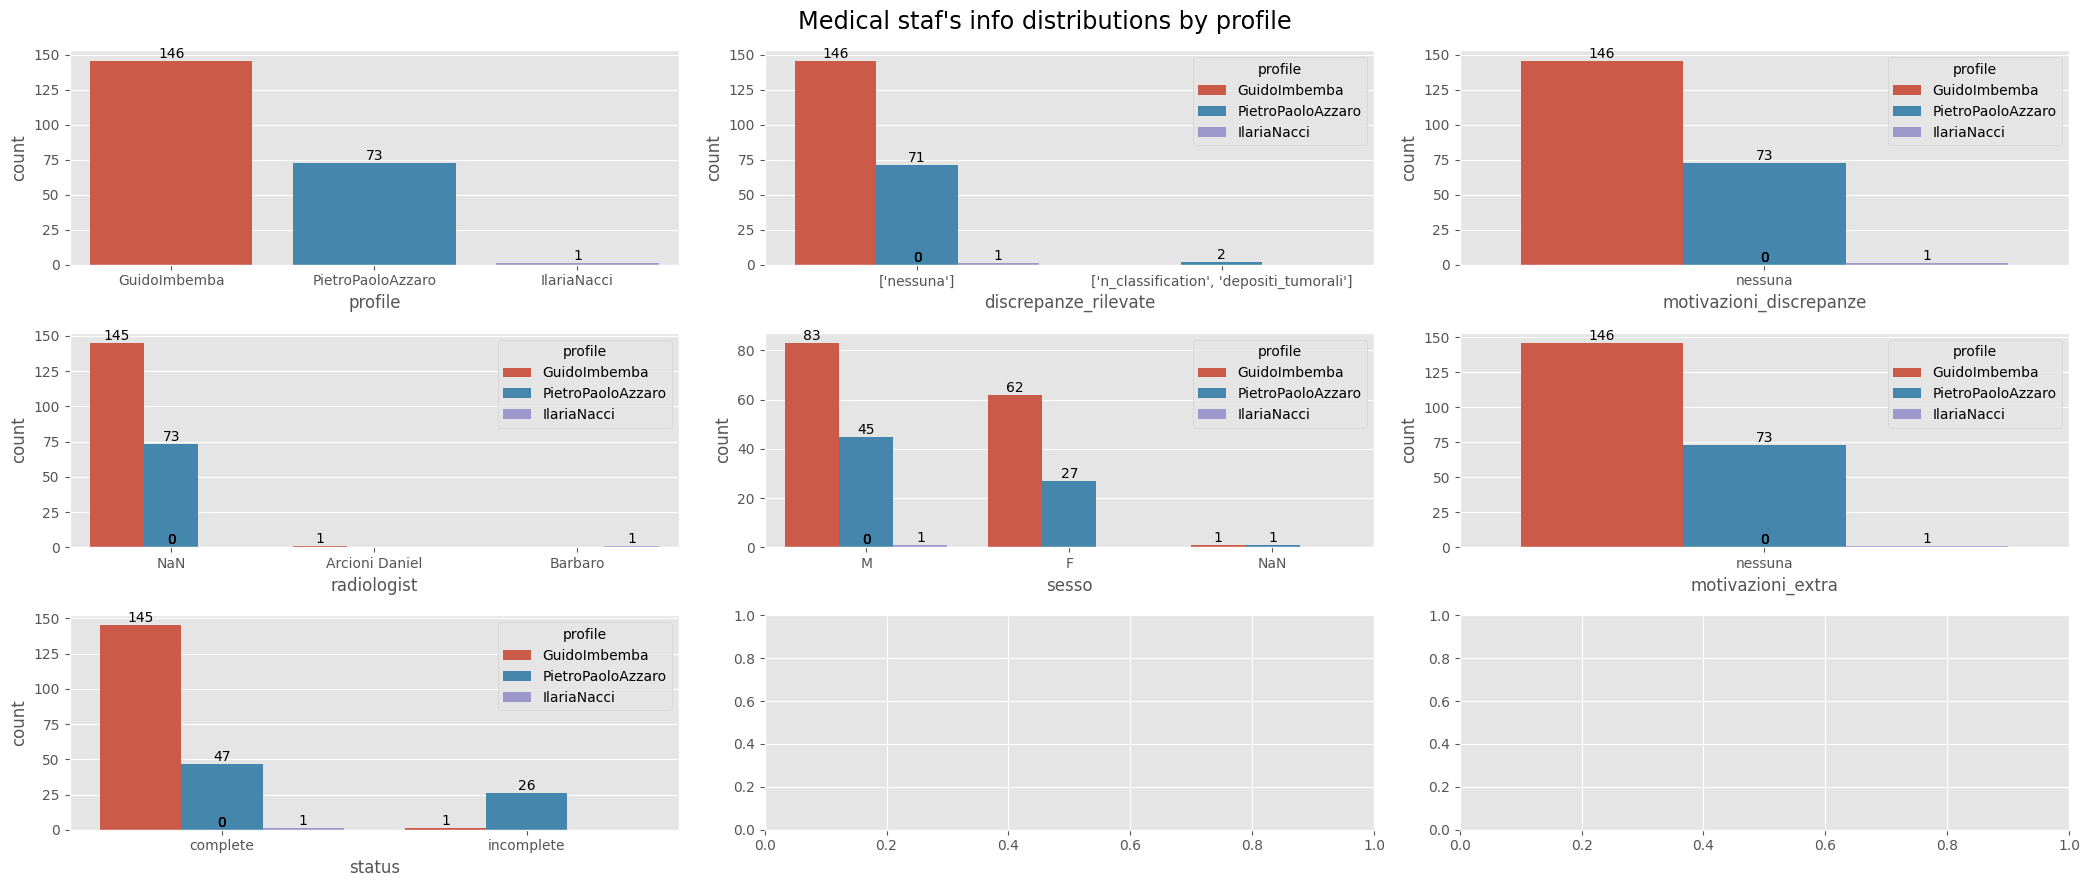

In [9]:
columns_plot = ['profile', 'discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']
#columns_plot = ['profile', 'status']
hue_column = 'profile'

data_x = pd.concat([data_plot, data_ilaria])
include_ilaria = True
print_statistics = False

n_columns = min(3, len(columns_plot))
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Medical staf's info distributions by profile", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    if n_rows == 1:
        ax = axes[i]
    else:
        ax=axes[i//n_columns][i%n_columns]
    if include_ilaria:
        sns.countplot(data=data_x, x=col, order=data_x[col].value_counts().index, ax=ax, hue=hue_column)
    else:
        sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_status_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

if print_statistics:
    columns = ['profile', 'discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']
    print(f'{len(columns) = }\n')
    for col in columns:
        print(data_clean[col].value_counts().to_frame().T)
        print("\n")

Ilaria told us to exclude Pietro's records. We also see how there is only one status = incomplete records of Guido.  

## Colonne target non numeriche

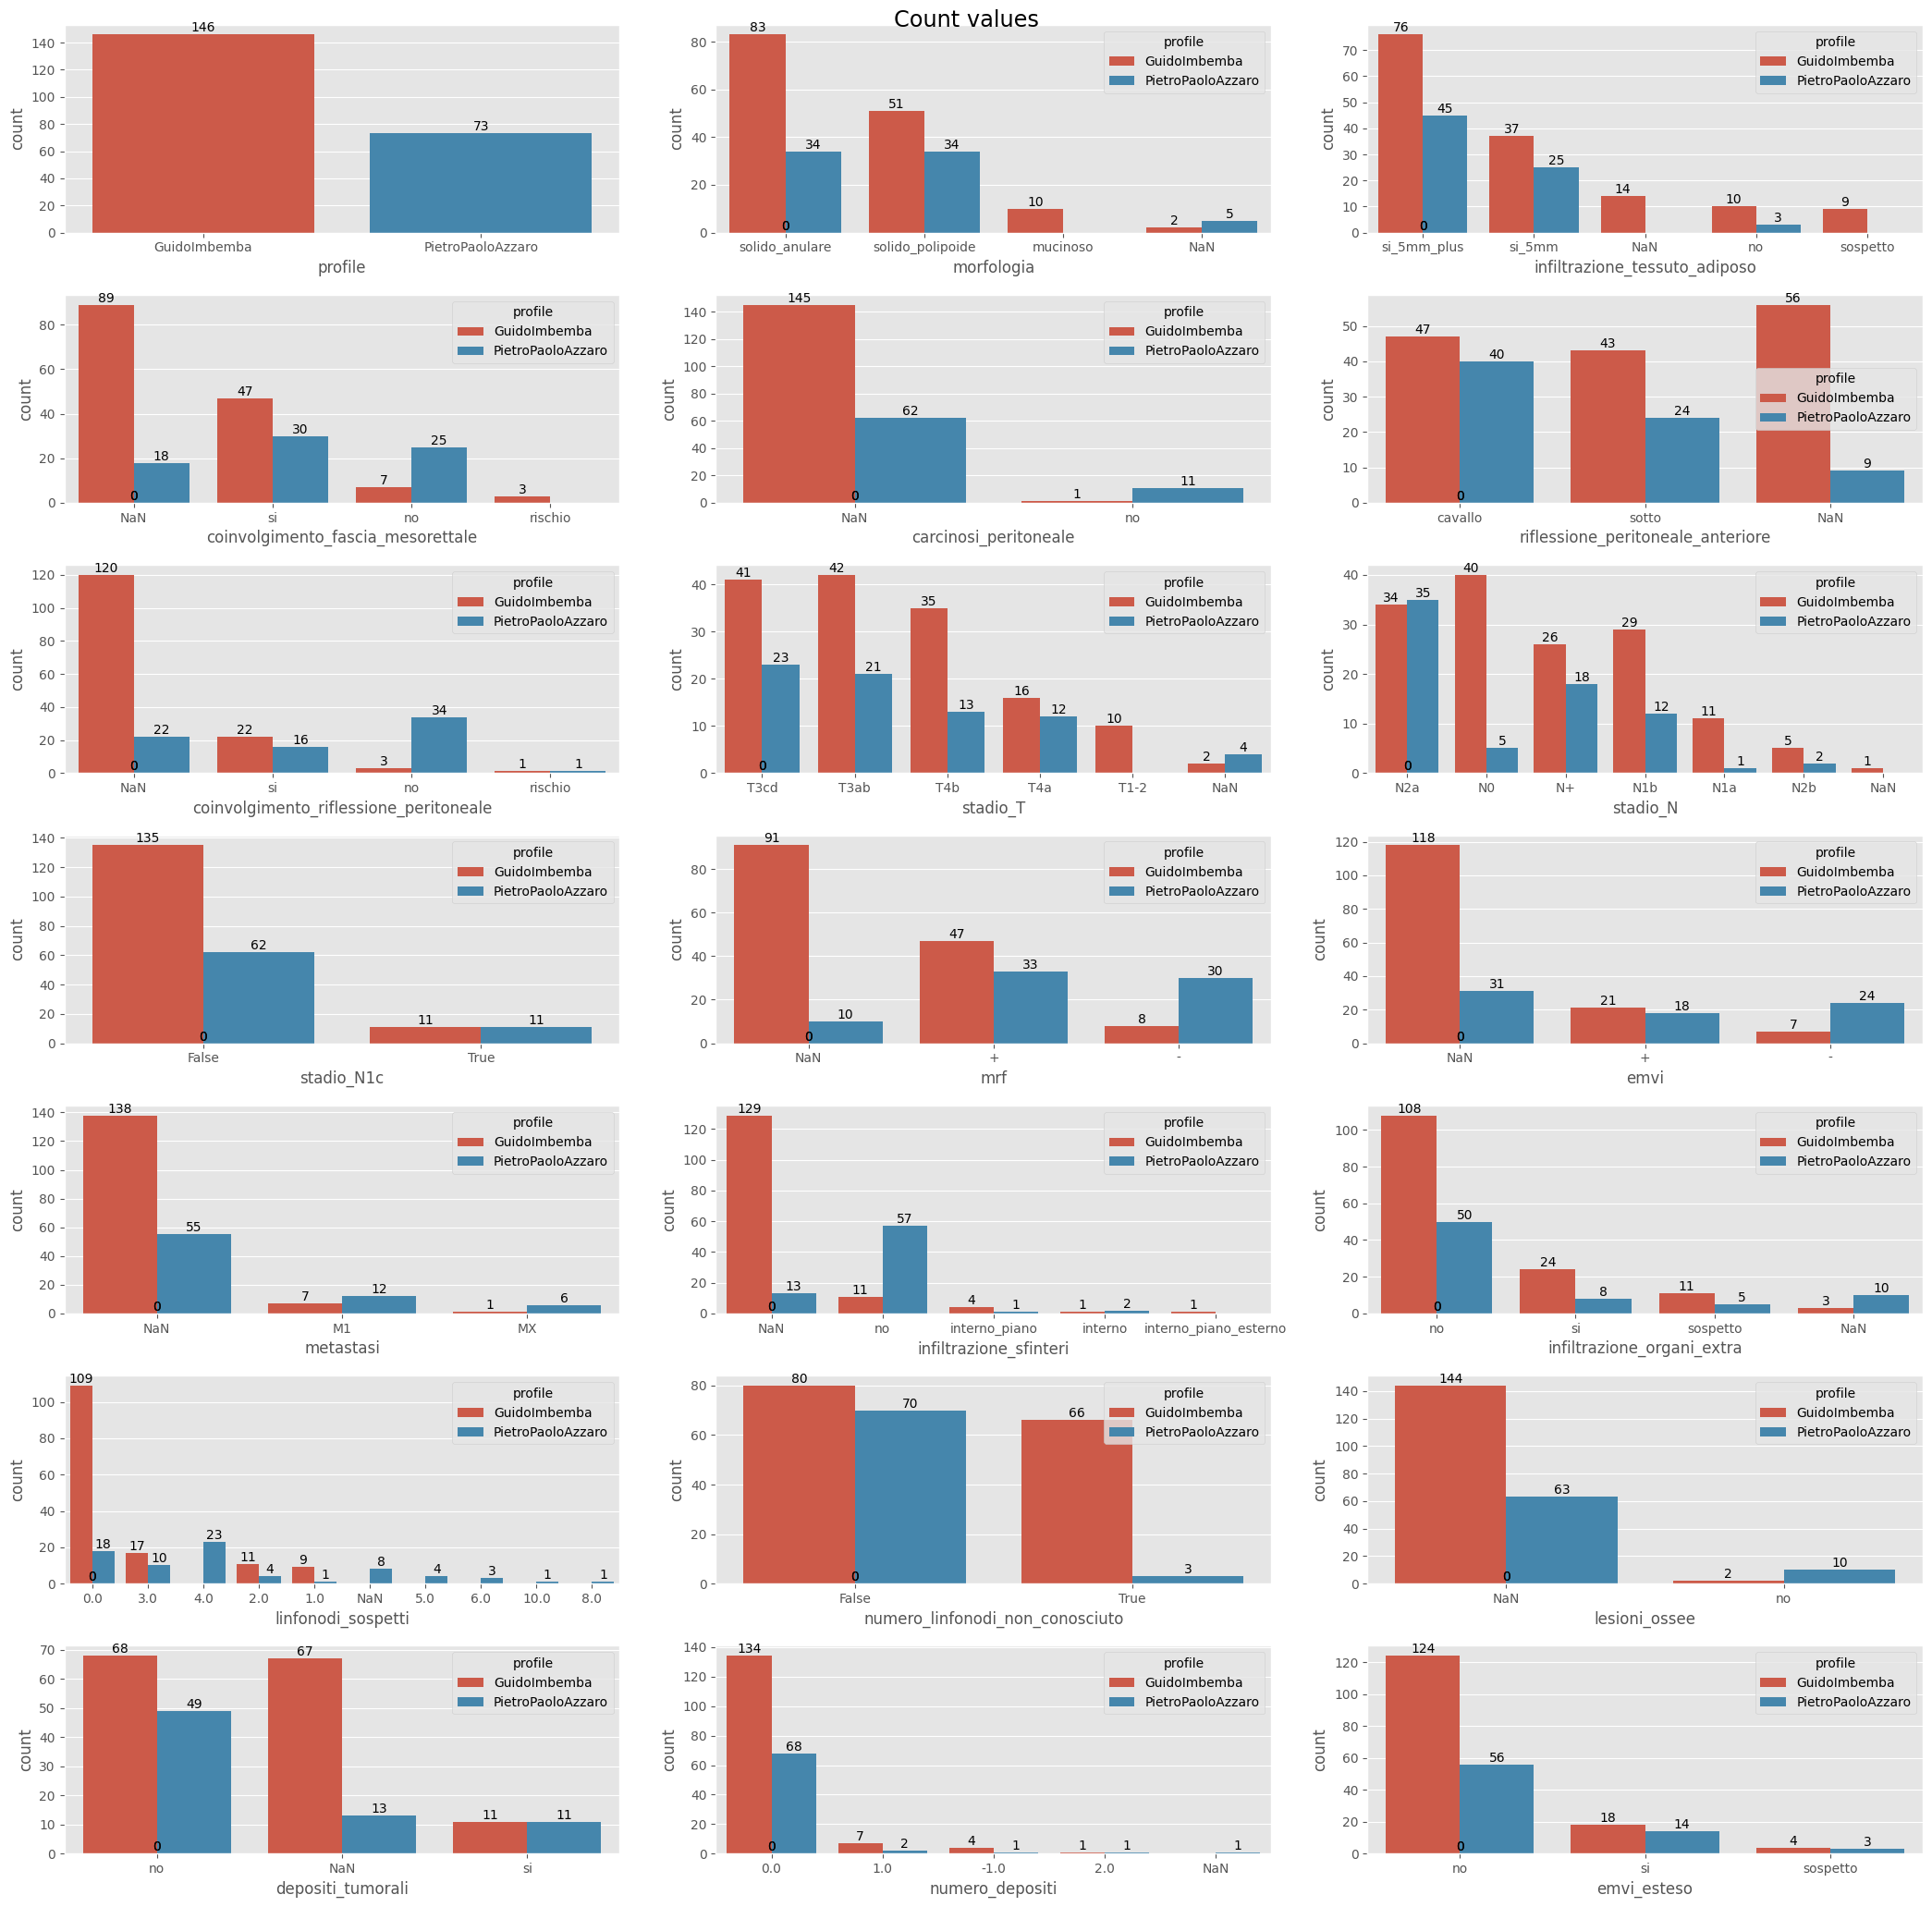

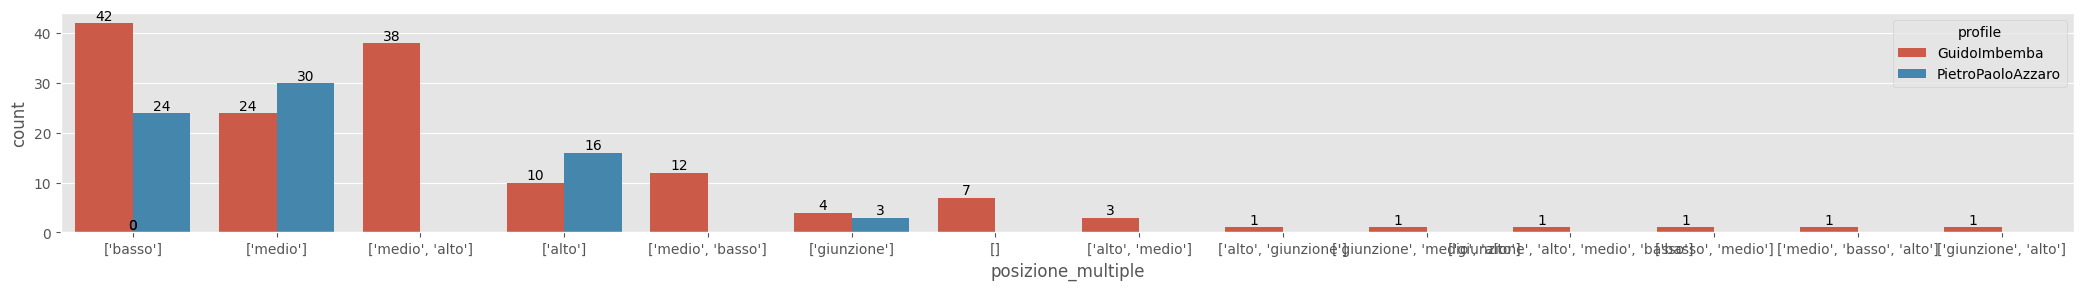

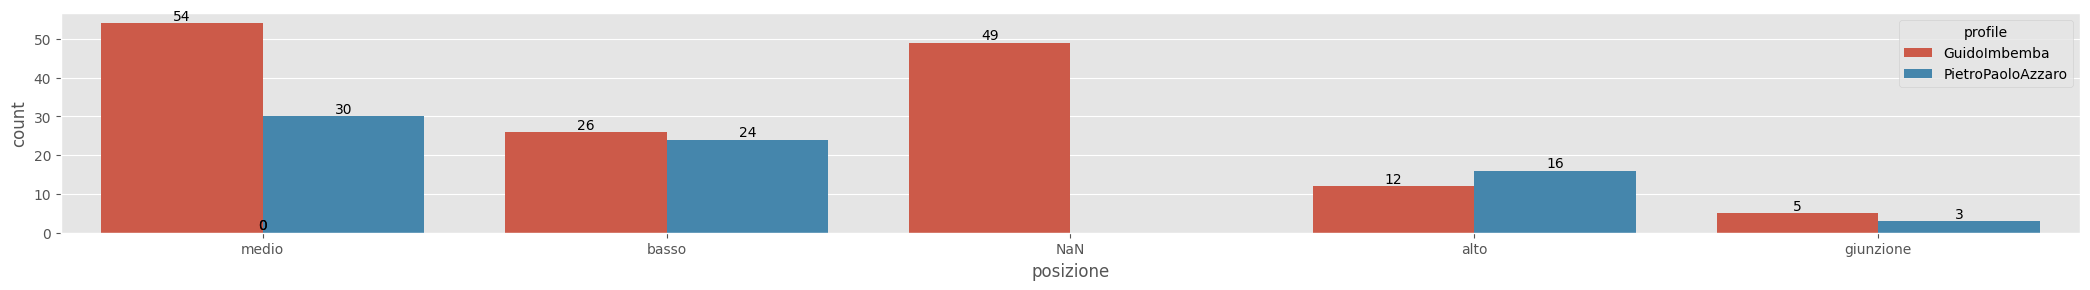

In [10]:
columns_plot = ['morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

hue_column = 'profile'
columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

fig, ax = plt.subplots(figsize=(21, 3))
sns.countplot(data=data_plot, x='posizione_multiple', order=data_plot['posizione_multiple'].value_counts().index, ax=ax, hue='profile')
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(21, 3))
sns.countplot(data=data_plot, x='posizione', order=data_plot['posizione'].value_counts().index, ax=ax, hue='profile')
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

**We see many anomalies between Guido and Pietro style of annortation. For this reason and also for what Ilaria told us, we will take into consideration only reports annotated by Guido**

In [11]:
data_clean_guido = data_clean[data_clean['profile'] == 'GuidoImbemba']

data_plot = data_clean_guido.fillna('NaN')

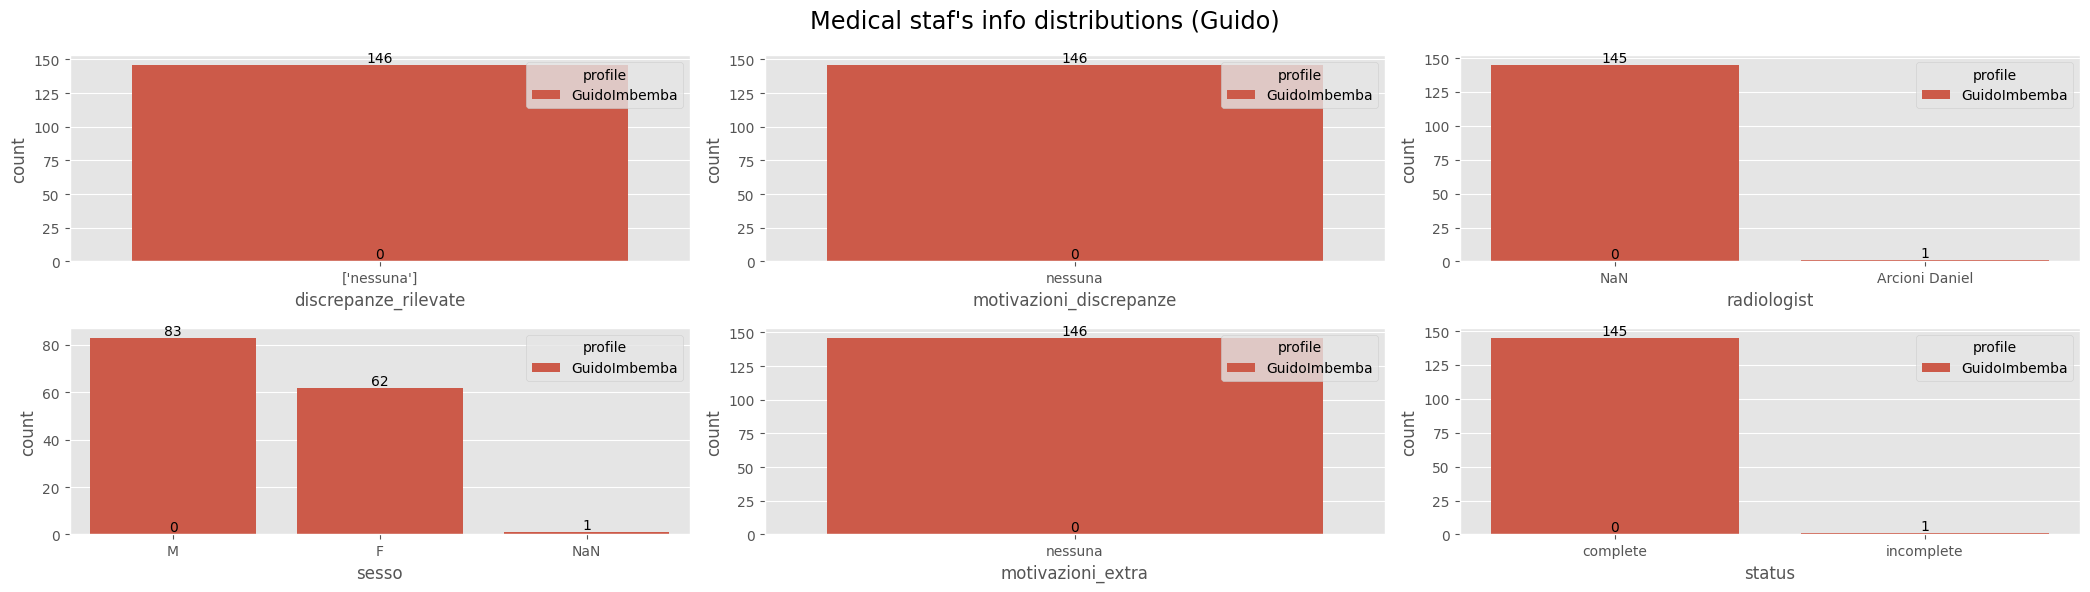

In [12]:


columns_plot = ['discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']
#columns_plot = ['profile', 'status']
#hue_column = 'status'

print_statistics = False

n_columns = min(3, len(columns_plot))
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Medical staf's info distributions (Guido)", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    if n_rows == 1:
        ax = axes[i]
    else:
        ax=axes[i//n_columns][i%n_columns]    
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_status_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

if print_statistics:
    print(f'{len(columns_plot) = }\n')
    for col in columns_plot:
        print(data_plot[col].value_counts().to_frame().T)
        print("\n")

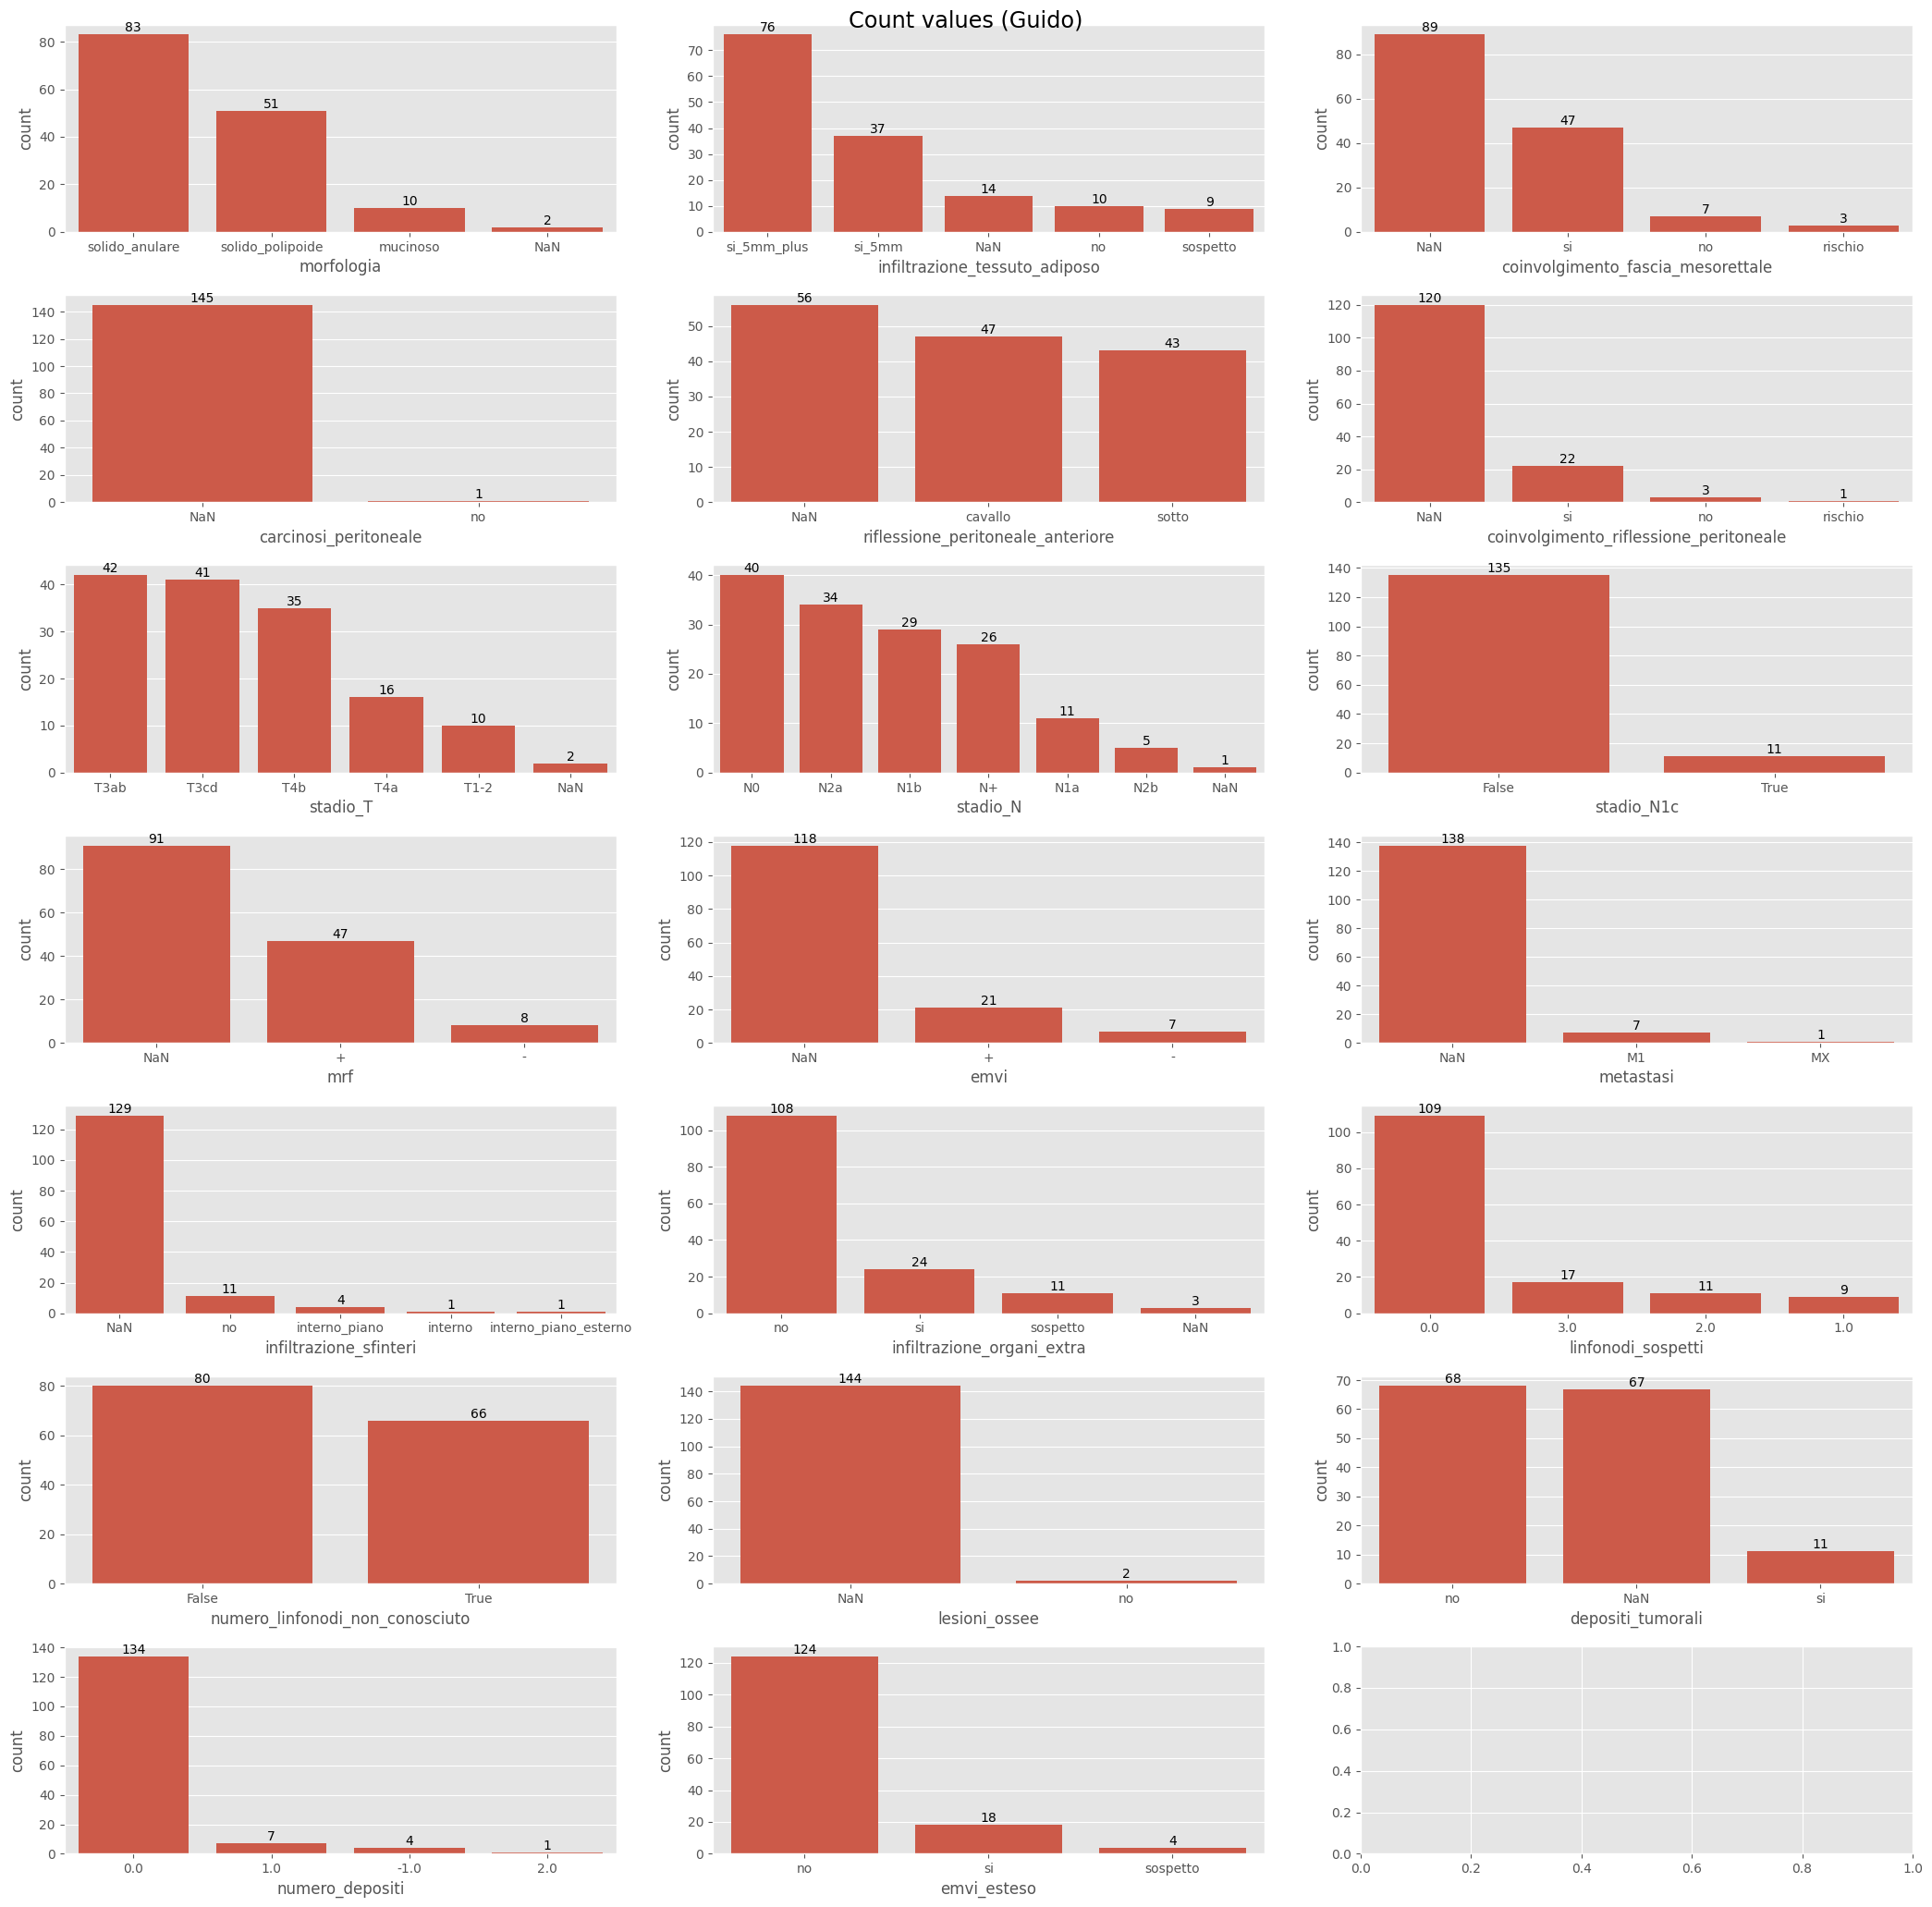

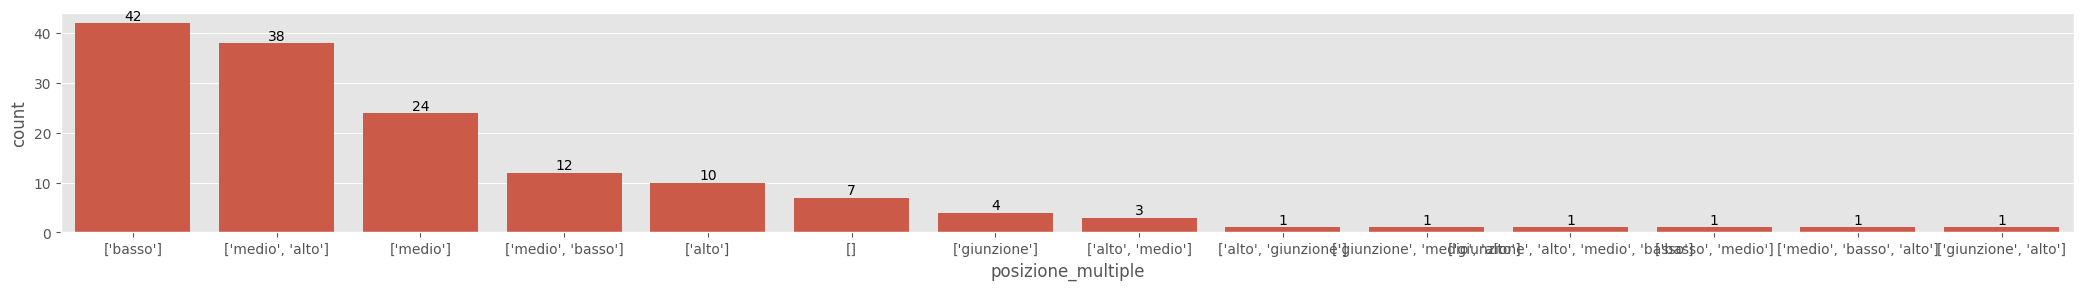

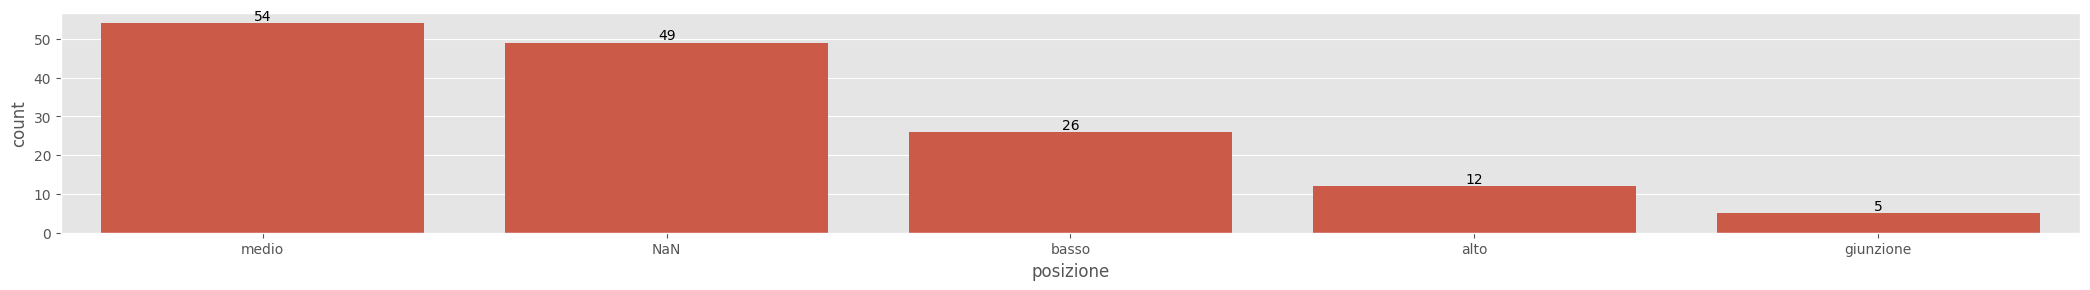

In [13]:
columns_plot = ['morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

hue_column = None
#columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values (Guido)", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()


fig, ax = plt.subplots(figsize=(21, 3))
sns.countplot(data=data_plot, x='posizione_multiple', order=data_plot['posizione_multiple'].value_counts().index, ax=ax, hue=hue_column)
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(21, 3))
sns.countplot(data=data_plot, x='posizione', order=data_plot['posizione'].value_counts().index, ax=ax, hue=hue_column)
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

{'giunzione': 8, 'NaN': 7, 'medio': 81, 'basso': 57, 'alto': 56}


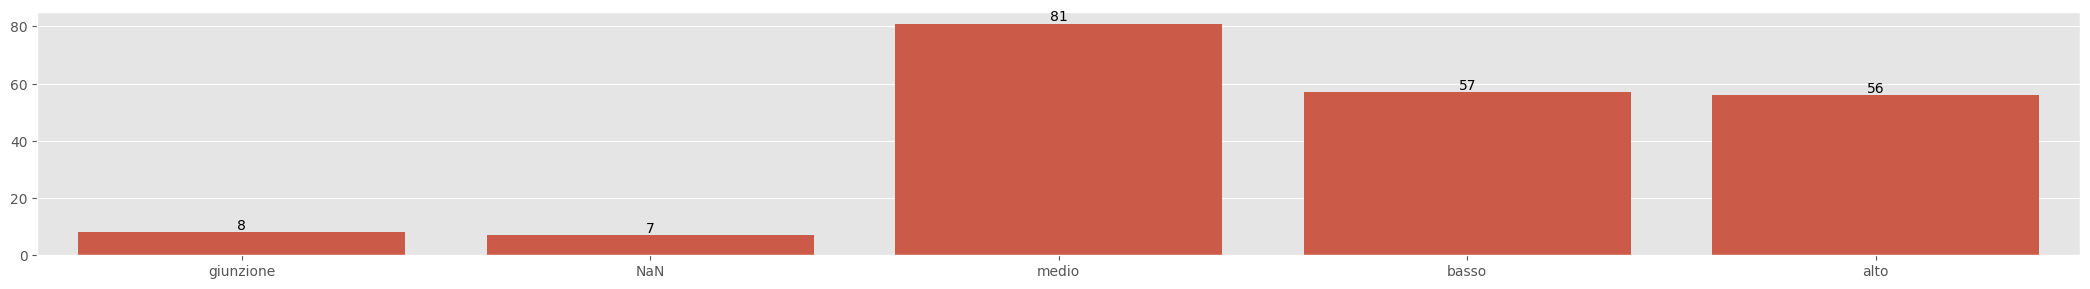

In [14]:
# Analisi posizione
positions = ['NaN']

for p in data_plot['posizione_multiple'].value_counts().index:
    positions += ast.literal_eval(p)
    
positions = list(set(positions))    
#print(f'{positions = }')

positions_counts = {pos: 0 for pos in positions}
for p in data_plot['posizione_multiple']:
    pos_list = ast.literal_eval(p)
    for pos in positions:
        if pos in pos_list:
            positions_counts[pos] += 1
    if pos_list == []:
        positions_counts['NaN'] += 1
            
print(positions_counts)

fig, ax = plt.subplots(figsize=(21, 3))
sns.barplot(data=positions_counts, ax=ax)
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [15]:
columns = ['infiltrazione_organi_dettagli', 'sedi_locoregionali', 'sedi_non_locoregionali'] 

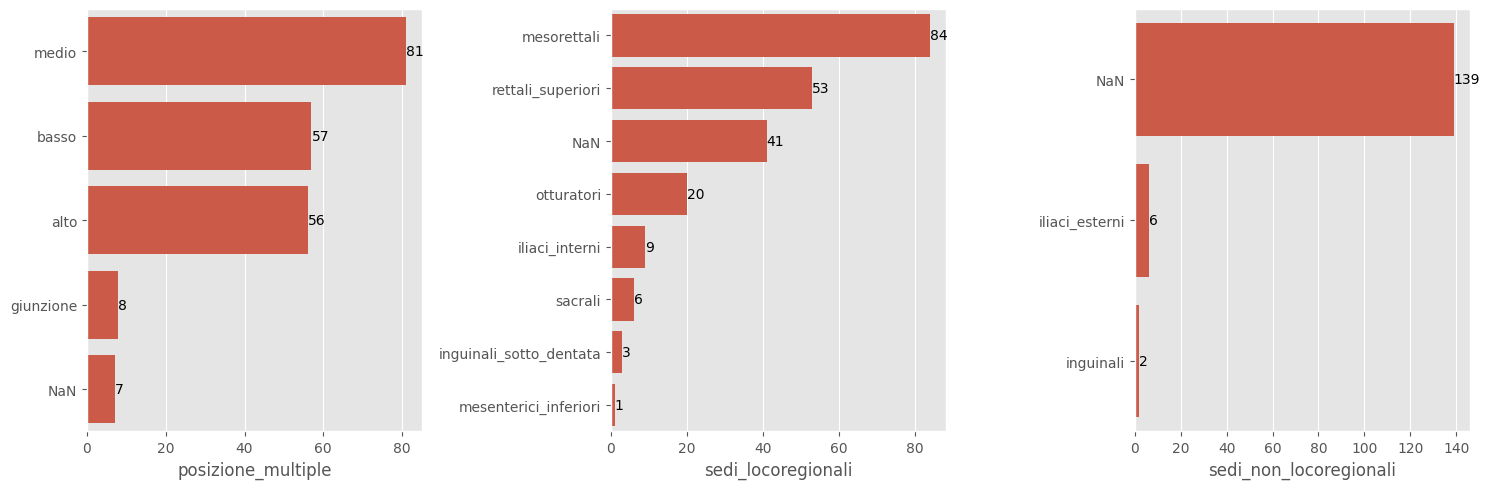

In [51]:
# Analisi posizione
columns = ['posizione_multiple', 'sedi_locoregionali', 'sedi_non_locoregionali']

possible_values = {col: ['NaN'] for col in columns}

for col in columns:
    for s in data_plot[col].value_counts().index:
        possible_values[col] += ast.literal_eval(s)
    possible_values[col] = list(set(possible_values[col]))    


counts = {
    col: {val: 0 for val in possible_values[col]}
    for col in columns
}
for col in columns:
    for s in data_plot[col]:
        value_list = ast.literal_eval(s)
        for value in possible_values[col]:
            if value in value_list:
                counts[col][value] += 1
        if value_list == []:
            counts[col]['NaN'] += 1
            
fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
for i, col in enumerate(columns):
    ax = axes[i]
    series = pd.Series(counts[col], name=col).sort_values(ascending=False)
    sns.barplot(data=series, ax=ax, orient='h')
    # Add values on top of bars
    #for p in ax.patches:
    #    y_text = int(p.get_height())
    #    x_text = p.get_x() + p.get_width() / 2
    #    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
    for p in ax.patches:
        x_text = p.get_width()
        y_text = p.get_y() + p.get_height() / 2
        ax.text(x=x_text, y=y_text, s=f'{int(x_text)}', va='center', ha='left')

plt.tight_layout()
plt.show()

In [18]:
data_clean_guido.sedi_non_locoregionali.value_counts()

sedi_non_locoregionali
[]                                 139
['iliaci_esterni']                   5
['inguinali']                        1
['iliaci_esterni', 'inguinali']      1
Name: count, dtype: int64

In [68]:
columns = ['posizione', 'posizione_multiple',
       'lesioni_ossee',
       
       
       'infiltrazione_organi_dettagli',
       
       
       'sedi_locoregionali', 'sedi_non_locoregionali']

print(f'{len(columns) = }\n')
for col in columns:
    print(data_clean.fillna('NaN')[col].value_counts().to_frame())
    print("\n")

len(columns) = 6

           count
posizione       
medio         84
NaN           50
basso         50
alto          28
giunzione      8


                                         count
posizione_multiple                            
['basso']                                   66
['medio']                                   54
['medio', 'alto']                           38
['alto']                                    26
['medio', 'basso']                          12
[]                                           8
['giunzione']                                7
['alto', 'medio']                            3
['alto', 'giunzione']                        1
['giunzione', 'medio', 'alto']               1
['giunzione', 'alto', 'medio', 'basso']      1
['basso', 'medio']                           1
['medio', 'basso', 'alto']                   1
['giunzione', 'alto']                        1


               count
lesioni_ossee       
NaN              207
no                12
si                 1




## Colonne target numeriche

In [11]:
colonne_target_numeriche = ['ore_inizio', 'ore_fine', 'dimensione_dll',
    'dimensione_dap', 'spessore_parietale', 'estensione_cranio_caudale',
    'distanza_oai', 'distanza_minima_fascia_ore',
    'linfonodi_sospetti', 'sedi_locoregionali', 'sedi_non_locoregionali',
    'depositi_tumorali', 'numero_depositi']

In [12]:
data_clean[colonne_target_numeriche].describe().T

,count,mean,std,min,25%,50%,75%,max
ore_inizio,76.0,9.250000,3.495235,1.0,6.00,12.0,12.00,12.0
ore_fine,76.0,9.710526,3.617792,1.0,6.75,12.0,12.00,12.0
dimensione_dll,14.0,41.642857,24.269662,15.0,24.00,38.0,47.25,105.0
dimensione_dap,11.0,48.090909,31.325563,21.0,30.00,38.0,50.50,120.0
spessore_parietale,44.0,19.681818,12.463477,7.0,12.00,16.5,22.00,60.0
estensione_cranio_caudale,210.0,49.257143,17.111528,18.0,37.25,48.5,57.75,130.0
distanza_oai,195.0,45.018974,28.086173,0.0,25.00,50.0,61.50,120.0
distanza_minima_fascia_ore,29.0,7.724138,3.624289,1.0,5.00,8.0,10.00,12.0
linfonodi_sospetti,212.0,1.297170,1.862931,0.0,0.00,0.0,3.00,10.0
numero_depositi,219.0,0.036530,0.315558,-1.0,0.00,0.0,0.00,2.0


escludere le segenti colonne perchè hanno troppi valori nulli:
- ore_inizio
- ore_fine
- dimensione_dll
- dimensione_dap
- distanza_minima_fascia_ore

## Colonne conclusioni

In [13]:
for col in ['stadio_T', 'stadio_N', 'stadio_N1c', 'mrf', 'emvi', 'metastasi']:
    print(data_clean.fillna('Nan')[col].value_counts())
    print("\n")

stadio_T
T3cd    64
T3ab    63
T4b     49
T4a     28
T1-2    10
Nan      6
Name: count, dtype: int64


stadio_N
N2a    69
N0     45
N+     44
N1b    41
N1a    12
N2b     7
Nan     1
N1c     1
Name: count, dtype: int64


stadio_N1c
False    198
True      22
Name: count, dtype: int64


mrf
Nan    101
+       81
-       38
Name: count, dtype: int64


emvi
Nan    149
+       39
-       32
Name: count, dtype: int64


metastasi
Nan    193
M1      20
MX       7
Name: count, dtype: int64


